# Lab Assignment 2 — Sentiment Analysis and Text Classification
**Author:** Matthew Cook
**ASU ID:** MCOOK20
**Course:** CIS 509: Analytics for Unstructured Data
**Date Created:** March 29, 2026

---

**Context:**
This assignment applies sentiment analysis and machine learning classification
to the same Arizona restaurant review dataset used in Lab Assignment 1.
The goal is to compare lexicon-based approaches (VADER) against supervised
ML classifiers (Naive Bayes, SVM) using two feature representations
(Count Vectorizer and TF-IDF) to determine which method best separates
positive from negative restaurant sentiment at scale.

In [ ]:
# Code Cell 1 — Install dependencies, library imports, Drive mount, data load

# Install VADER (not pre-installed in Colab)
!pip install vaderSentiment -q

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# NLP / ML libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Load the restaurant reviews dataset
file_path = '/content/drive/MyDrive/Colab Notebooks/restaurant_reviews_az.csv'
df = pd.read_csv(file_path)

# Dataset summary
print("=== Dataset Shape ===")
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")

print("\n=== Column Info ===")
print(df.dtypes)

print("\n=== Star Rating Distribution ===")
print(df['stars'].value_counts().sort_index())

print("\n=== Null Check ===")
print(df.isnull().sum())

print("\n=== Sample Reviews ===")
df[['stars', 'text']].head(3)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.8 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== Dataset Shape ===
Rows: 48,147  |  Columns: 9

=== Column Info ===
review_id      object
user_id        object
business_id    object
stars           int64
useful          int64
funny           int64
cool            int64
text           object
date           object
dtype: object

=== Star Rating Distribution ===
stars
1     8466
2     3846
3     4054
4     7314
5    24467
Name: count, dtype: int64

=== Null Check ===
review_id      0
user_id        0
business_id    0
stars          0
useful         0
funny          0
cool           0
text           0
date           0
dtype: int64

=== Sample Reviews ===


,stars,text
0,3,"OK, the hype about having Hatch chili in your ..."
1,5,Pandemic pit stop to have an ice cream.... onl...
2,5,I was lucky enough to go to the soft opening a...


=== Rows after removing 3-star reviews ===
Original:  48,147
Remaining: 44,093
Removed:   4,054 (3-star reviews)

=== Sentiment Distribution ===
Negative (0): 12,312  (27.9%)
Positive (1): 31,781  (72.1%)

=== Star-to-Sentiment Mapping Verification ===
   stars  Sentiment  count
0      1          0   8466
1      2          0   3846
2      4          1   7314
3      5          1  24467


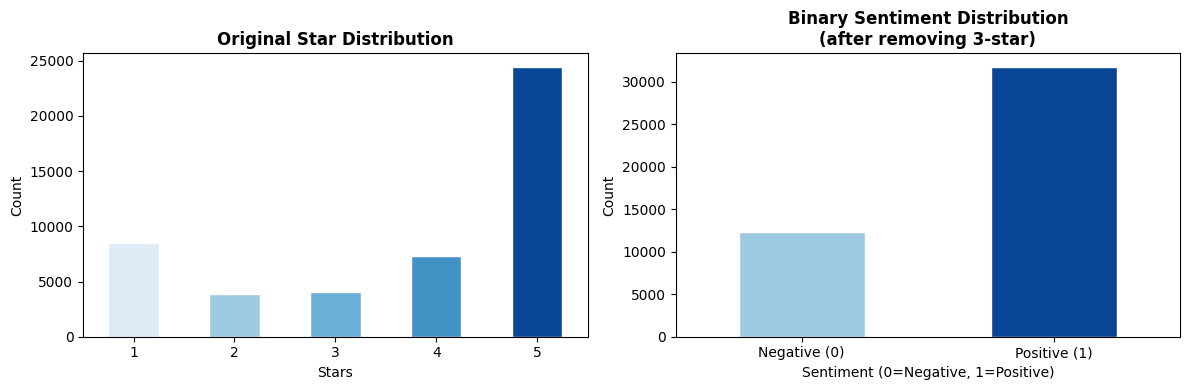


Chart saved.


In [ ]:
# Code Cell 2 — Remove 3-star reviews, create binary Sentiment column
# 1-2 star reviews → Sentiment = 0 (negative)
# 4-5 star reviews → Sentiment = 1 (positive)
# 3-star reviews removed — ambiguous signal, not useful for binary classification

# Remove 3-star reviews
df_binary = df[df['stars'] != 3].copy()

# Create binary Sentiment column
df_binary['Sentiment'] = df_binary['stars'].apply(lambda x: 0 if x <= 2 else 1)

# Confirmation output
print("=== Rows after removing 3-star reviews ===")
print(f"Original:  {len(df):,}")
print(f"Remaining: {len(df_binary):,}")
print(f"Removed:   {len(df) - len(df_binary):,} (3-star reviews)")

print("\n=== Sentiment Distribution ===")
sentiment_counts = df_binary['Sentiment'].value_counts().sort_index()
print(f"Negative (0): {sentiment_counts[0]:,}  "
      f"({sentiment_counts[0]/len(df_binary)*100:.1f}%)")
print(f"Positive (1): {sentiment_counts[1]:,}  "
      f"({sentiment_counts[1]/len(df_binary)*100:.1f}%)")

print("\n=== Star-to-Sentiment Mapping Verification ===")
print(df_binary.groupby(['stars','Sentiment']).size().reset_index(name='count'))

# Visual distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before - Using Blue shades
df['stars'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=['#deebf7','#9ecae1','#6baed6','#4292c6','#084594'],
    edgecolor='white')
axes[0].set_title('Original Star Distribution', fontweight='bold')
axes[0].set_xlabel('Stars')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# After — binary sentiment - Using Blues
sentiment_counts.plot(
    kind='bar', ax=axes[1],
    color=['#9ecae1','#084594'], edgecolor='white')
axes[1].set_title('Binary Sentiment Distribution\n(after removing 3-star)', fontweight='bold')
axes[1].set_xlabel('Sentiment (0=Negative, 1=Positive)')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['Negative (0)', 'Positive (1)'], rotation=0)

plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved.")

In [ ]:
# Code Cell 3 — Data preprocessing and train/test split
# 80% training, 20% testing as required
# Text column is the feature, Sentiment column is the target label

import re

# --- Text cleaning function ---
# Lowercase, remove punctuation and digits, strip extra whitespace
# Cleaner input = better vectorization signal

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply cleaning to the text column
df_binary['clean_text'] = df_binary['text'].apply(clean_text)

# --- Define features and target ---
X = df_binary['clean_text']
y = df_binary['Sentiment']

# --- Train/test split: 80% train, 20% test ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y   # preserve class imbalance ratio in both splits
)

# --- Confirmation output ---
print("=== Train/Test Split Summary ===")
print(f"Total records:    {len(df_binary):,}")
print(f"Training set:     {len(X_train):,}  ({len(X_train)/len(df_binary)*100:.0f}%)")
print(f"Test set:         {len(X_test):,}   ({len(X_test)/len(df_binary)*100:.0f}%)")

print("\n=== Class Distribution — Training Set ===")
train_dist = y_train.value_counts().sort_index()
print(f"Negative (0): {train_dist[0]:,}  ({train_dist[0]/len(y_train)*100:.1f}%)")
print(f"Positive (1): {train_dist[1]:,}  ({train_dist[1]/len(y_train)*100:.1f}%)")

print("\n=== Class Distribution — Test Set ===")
test_dist = y_test.value_counts().sort_index()
print(f"Negative (0): {test_dist[0]:,}  ({test_dist[0]/len(y_test)*100:.1f}%)")
print(f"Positive (1): {test_dist[1]:,}  ({test_dist[1]/len(y_test)*100:.1f}%)")

print("\n=== Sample Cleaned Text ===")
pd.DataFrame({
    'original': df_binary['text'].head(3).values,
    'cleaned':  df_binary['clean_text'].head(3).values
})

=== Train/Test Split Summary ===
Total records:    44,093
Training set:     35,274  (80%)
Test set:         8,819   (20%)

=== Class Distribution — Training Set ===
Negative (0): 9,849  (27.9%)
Positive (1): 25,425  (72.1%)

=== Class Distribution — Test Set ===
Negative (0): 2,463  (27.9%)
Positive (1): 6,356  (72.1%)

=== Sample Cleaned Text ===


,original,cleaned
0,Pandemic pit stop to have an ice cream.... onl...,pandemic pit stop to have an ice cream only pl...
1,I was lucky enough to go to the soft opening a...,i was lucky enough to go to the soft opening a...
2,I've gone to claim Jumpers all over the US and...,i ve gone to claim jumpers all over the us and...


In [ ]:
# Code Cell 4 — Count Vectorizer with frequency count
# Max features: 1000 as required
# Fit on training data only — never on test data (prevents data leakage)

# --- Build Count Vectorizer ---
count_vectorizer = CountVectorizer(
    max_features=1000,
    stop_words='english',   # remove common words that carry no sentiment signal
    min_df=2                # ignore terms appearing in fewer than 2 documents
)

# Fit on training set, transform both train and test
X_train_cv = count_vectorizer.fit_transform(X_train)
X_test_cv  = count_vectorizer.transform(X_test)

# --- Summary output ---
print("=== Count Vectorizer Summary ===")
print(f"Vocabulary size:       {len(count_vectorizer.vocabulary_):,} features")
print(f"Training matrix shape: {X_train_cv.shape}")
print(f"Test matrix shape:     {X_test_cv.shape}")
print(f"Matrix type:           {type(X_train_cv).__name__} (sparse)")
print(f"Matrix density:        "
      f"{X_train_cv.nnz / (X_train_cv.shape[0] * X_train_cv.shape[1]):.4%}")

print("\n=== Top 20 Most Frequent Terms (training set) ===")
import numpy as np
term_freq = np.asarray(X_train_cv.sum(axis=0)).flatten()
vocab = count_vectorizer.get_feature_names_out()
top20_idx = term_freq.argsort()[::-1][:20]
for i, idx in enumerate(top20_idx, 1):
    print(f"  {i:>2}. {vocab[idx]:<20} {int(term_freq[idx]):,}")

=== Count Vectorizer Summary ===
Vocabulary size:       1,000 features
Training matrix shape: (35274, 1000)
Test matrix shape:     (8819, 1000)
Matrix type:           csr_matrix (sparse)
Matrix density:        2.4027%

=== Top 20 Most Frequent Terms (training set) ===
   1. food                 25,098
   2. good                 15,769
   3. place                14,072
   4. great                13,843
   5. service              11,711
   6. time                 10,260
   7. order                9,488
   8. just                 9,309
   9. like                 8,430
  10. ordered              8,194
  11. delicious            7,682
  12. got                  7,172
  13. restaurant           6,716
  14. ve                   6,342
  15. really               6,273
  16. chicken              5,895
  17. tucson               5,799
  18. best                 5,768
  19. staff                5,539
  20. amazing              5,383


=== Naive Bayes — Count Vectorizer ===
Accuracy: 0.9168  (91.68%)

=== Classification Report ===
              precision    recall  f1-score   support

Negative (0)       0.86      0.84      0.85      2463
Positive (1)       0.94      0.95      0.94      6356

    accuracy                           0.92      8819
   macro avg       0.90      0.89      0.90      8819
weighted avg       0.92      0.92      0.92      8819



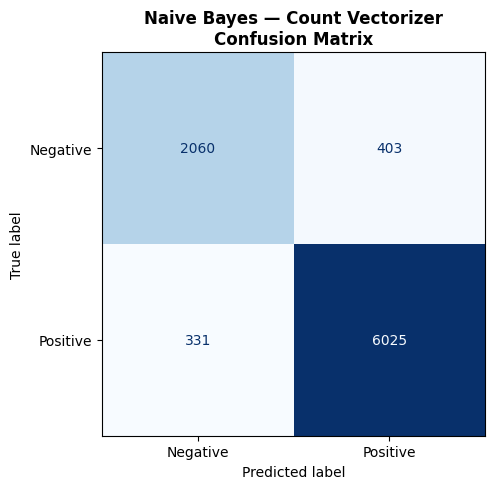


=== Top 15 Words Predicting NEGATIVE sentiment ===
  food
  order
  time
  just
  place
  service
  like
  ordered
  good
  got
  minutes
  said
  don
  restaurant
  asked

=== Top 15 Words Predicting POSITIVE sentiment ===
  food
  good
  great
  place
  service
  delicious
  time
  just
  best
  amazing
  tucson
  like
  really
  ordered
  ve


In [ ]:
# Code Cell 5 — Naive Bayes classifier using Count Vectorizer features
# Multinomial NB is purpose-built for word frequency data
# Evaluate with accuracy, classification report, and confusion matrix

# --- Train Naive Bayes on Count Vectorizer features ---
nb_cv = MultinomialNB()
nb_cv.fit(X_train_cv, y_train)

# --- Predict on test set ---
y_pred_nb_cv = nb_cv.predict(X_test_cv)

# --- Evaluation ---
nb_cv_accuracy = accuracy_score(y_test, y_pred_nb_cv)

print("=== Naive Bayes — Count Vectorizer ===")
print(f"Accuracy: {nb_cv_accuracy:.4f}  ({nb_cv_accuracy*100:.2f}%)")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_nb_cv,
                             target_names=['Negative (0)', 'Positive (1)']))

# --- Confusion matrix ---
cm_nb_cv = confusion_matrix(y_test, y_pred_nb_cv)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_nb_cv,
                               display_labels=['Negative', 'Positive'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Naive Bayes — Count Vectorizer\nConfusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('nb_cv_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Top predictive words per class ---
print("\n=== Top 15 Words Predicting NEGATIVE sentiment ===")
neg_idx = nb_cv.feature_log_prob_[0].argsort()[::-1][:15]
vocab = count_vectorizer.get_feature_names_out()
for word in vocab[neg_idx]:
    print(f"  {word}")

print("\n=== Top 15 Words Predicting POSITIVE sentiment ===")
pos_idx = nb_cv.feature_log_prob_[1].argsort()[::-1][:15]
for word in vocab[pos_idx]:
    print(f"  {word}")

=== SVM — Count Vectorizer ===
Accuracy: 0.9408  (94.08%)

=== Classification Report ===
              precision    recall  f1-score   support

Negative (0)       0.91      0.88      0.89      2463
Positive (1)       0.95      0.97      0.96      6356

    accuracy                           0.94      8819
   macro avg       0.93      0.92      0.93      8819
weighted avg       0.94      0.94      0.94      8819



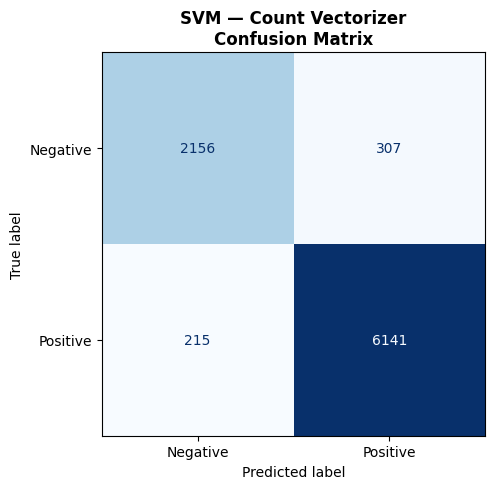


=== CV Feature Model Comparison So Far ===
  Naive Bayes accuracy: 91.68%
  SVM accuracy:         94.08%
  Delta:                +2.40%


In [ ]:
# Code Cell 6 — SVM classifier using Count Vectorizer features
# LinearSVC is the standard SVM for high-dimensional text classification
# Faster and more memory-efficient than kernel SVM on sparse matrices

# --- Train SVM on Count Vectorizer features ---
svm_cv = LinearSVC(random_state=42, max_iter=2000)
svm_cv.fit(X_train_cv, y_train)

# --- Predict on test set ---
y_pred_svm_cv = svm_cv.predict(X_test_cv)

# --- Evaluation ---
svm_cv_accuracy = accuracy_score(y_test, y_pred_svm_cv)

print("=== SVM — Count Vectorizer ===")
print(f"Accuracy: {svm_cv_accuracy:.4f}  ({svm_cv_accuracy*100:.2f}%)")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_svm_cv,
                             target_names=['Negative (0)', 'Positive (1)']))

# --- Confusion matrix ---
cm_svm_cv = confusion_matrix(y_test, y_pred_svm_cv)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm_cv,
                               display_labels=['Negative', 'Positive'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('SVM — Count Vectorizer\nConfusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('svm_cv_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Quick comparison vs Naive Bayes ---
print("\n=== CV Feature Model Comparison So Far ===")
print(f"  Naive Bayes accuracy: 91.68%")
print(f"  SVM accuracy:         {svm_cv_accuracy*100:.2f}%")
print(f"  Delta:                {(svm_cv_accuracy - 0.9168)*100:+.2f}%")

In [ ]:
# Code Cell 7 — TF-IDF Vectorizer, max features 1000
# TF-IDF (Term Frequency-Inverse Document Frequency) improves on raw counts
# by penalizing words that appear across many documents
# Words like "food" and "good" appear in nearly every review — TF-IDF
# reduces their weight so rare, distinctive terms carry more signal
# This is directly relevant to TABHS: fake reviews use generic high-frequency
# words; authentic reviews use specific, low-frequency descriptive language

# --- Build TF-IDF Vectorizer ---
tfidf_vectorizer = TfidfVectorizer(
    max_features=1000,
    stop_words='english',
    min_df=2,
    sublinear_tf=True   # apply log normalization to term frequencies
                        # reduces the weight of very high-frequency terms
)

# Fit on training set only, transform both splits
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

# --- Summary ---
print("=== TF-IDF Vectorizer Summary ===")
print(f"Vocabulary size:       {len(tfidf_vectorizer.vocabulary_):,} features")
print(f"Training matrix shape: {X_train_tfidf.shape}")
print(f"Test matrix shape:     {X_test_tfidf.shape}")
print(f"Matrix density:        "
      f"{X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]):.4%}")

# --- Top 20 terms by mean TF-IDF weight (training set) ---
print("\n=== Top 20 Terms by Mean TF-IDF Weight (training set) ===")
mean_tfidf = np.asarray(X_train_tfidf.mean(axis=0)).flatten()
vocab_tfidf = tfidf_vectorizer.get_feature_names_out()
top20_tfidf_idx = mean_tfidf.argsort()[::-1][:20]
for i, idx in enumerate(top20_tfidf_idx, 1):
    print(f"  {i:>2}. {vocab_tfidf[idx]:<20} {mean_tfidf[idx]:.5f}")

# --- Compare top terms: Count Vectorizer vs TF-IDF ---
print("\n=== Key Difference: Count Vectorizer vs TF-IDF Top Terms ===")
cv_top10   = list(count_vectorizer.get_feature_names_out()[
    np.asarray(X_train_cv.sum(axis=0)).flatten().argsort()[::-1][:10]])
tfidf_top10 = list(vocab_tfidf[mean_tfidf.argsort()[::-1][:10]])
print(f"  Count Vectorizer: {cv_top10}")
print(f"  TF-IDF:           {tfidf_top10}")
print("\n  TF-IDF shifts weight toward distinctive terms.")
print("  Generic words lose influence. Specific descriptors gain it.")

=== TF-IDF Vectorizer Summary ===
Vocabulary size:       1,000 features
Training matrix shape: (35274, 1000)
Test matrix shape:     (8819, 1000)
Matrix density:        2.4027%

=== Top 20 Terms by Mean TF-IDF Weight (training set) ===
   1. food                 0.05184
   2. great                0.04116
   3. good                 0.03941
   4. place                0.03723
   5. service              0.03564
   6. time                 0.02771
   7. delicious            0.02713
   8. just                 0.02410
   9. order                0.02409
  10. best                 0.02320
  11. amazing              0.02308
  12. like                 0.02277
  13. ordered              0.02191
  14. staff                0.02153
  15. tucson               0.02152
  16. love                 0.02124
  17. restaurant           0.02085
  18. ve                   0.02079
  19. got                  0.02068
  20. friendly             0.02041

=== Key Difference: Count Vectorizer vs TF-IDF Top Terms ===
  C

=== Naive Bayes — TF-IDF ===
Accuracy: 0.9053  (90.53%)

=== Classification Report ===
              precision    recall  f1-score   support

Negative (0)       0.92      0.73      0.81      2463
Positive (1)       0.90      0.98      0.94      6356

    accuracy                           0.91      8819
   macro avg       0.91      0.85      0.87      8819
weighted avg       0.91      0.91      0.90      8819



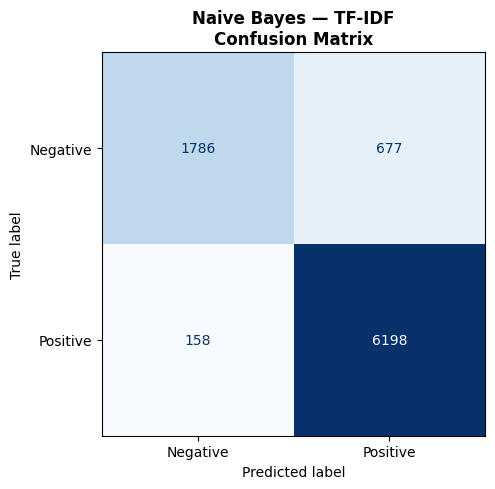


=== Running Model Scoreboard ===
  Model                            Accuracy    Neg F1    Pos F1
  ----------------------------------------------------------
  NB — Count Vectorizer              91.68%      0.85      0.94
  SVM — Count Vectorizer             94.08%      0.89      0.96
  NB — TF-IDF                        90.53%      0.81      0.94


In [ ]:
# Code Cell 8 — Naive Bayes with TF-IDF features
# Same NB architecture as Cell 5, now fed TF-IDF weights instead of raw counts
# TF-IDF should help NB by reducing the dominance of high-frequency neutral words
# Direct comparison to Cell 5 shows whether feature representation matters more
# than model choice — critical insight for TABHS project feature engineering

# --- Train Naive Bayes on TF-IDF features ---
# Note: TF-IDF produces float values — need to shift to non-negative
# MultinomialNB requires non-negative features; TF-IDF values are always >= 0
nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)

# --- Predict ---
y_pred_nb_tfidf = nb_tfidf.predict(X_test_tfidf)

# --- Evaluation ---
nb_tfidf_accuracy = accuracy_score(y_test, y_pred_nb_tfidf)

print("=== Naive Bayes — TF-IDF ===")
print(f"Accuracy: {nb_tfidf_accuracy:.4f}  ({nb_tfidf_accuracy*100:.2f}%)")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_nb_tfidf,
                             target_names=['Negative (0)', 'Positive (1)']))

# --- Confusion matrix ---
cm_nb_tfidf = confusion_matrix(y_test, y_pred_nb_tfidf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_nb_tfidf,
                               display_labels=['Negative', 'Positive'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Naive Bayes — TF-IDF\nConfusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('nb_tfidf_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Running scoreboard ---
print("\n=== Running Model Scoreboard ===")
print(f"  {'Model':<30} {'Accuracy':>10}  {'Neg F1':>8}  {'Pos F1':>8}")
print(f"  {'-'*58}")
print(f"  {'NB — Count Vectorizer':<30} {'91.68%':>10}  {'0.85':>8}  {'0.94':>8}")
print(f"  {'SVM — Count Vectorizer':<30} {'94.08%':>10}  {'0.89':>8}  {'0.96':>8}")
print(f"  {'NB — TF-IDF':<30} {nb_tfidf_accuracy*100:>9.2f}%", end="")

from sklearn.metrics import f1_score
neg_f1 = f1_score(y_test, y_pred_nb_tfidf, pos_label=0)
pos_f1 = f1_score(y_test, y_pred_nb_tfidf, pos_label=1)
print(f"  {neg_f1:>8.2f}  {pos_f1:>8.2f}")

=== SVM — TF-IDF ===
Accuracy: 0.9421  (94.21%)

=== Classification Report ===
              precision    recall  f1-score   support

Negative (0)       0.91      0.88      0.89      2463
Positive (1)       0.95      0.97      0.96      6356

    accuracy                           0.94      8819
   macro avg       0.93      0.92      0.93      8819
weighted avg       0.94      0.94      0.94      8819



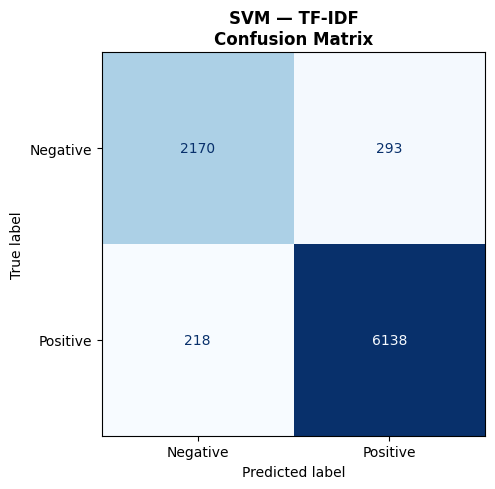


=== Full ML Model Scoreboard ===
  Model                            Accuracy    Neg F1    Pos F1
  ------------------------------------------------------------
  NB — Count Vectorizer              91.68%      0.85      0.94
  SVM — Count Vectorizer             94.08%      0.89      0.96
  NB — TF-IDF                        90.53%      0.81      0.94
  SVM — TF-IDF                       94.21%      0.89      0.96

  Best ML model accuracy: 94.21%
  VADER (lexicon) runs next — Cell 10 will show whether
  a rule-based approach can compete with trained models.


In [ ]:
# Code Cell 9 — SVM with TF-IDF features
# Expected to be the top performer — SVM handles weighted continuous TF-IDF
# values better than NB because it finds the optimal decision boundary
# without the independence assumption NB requires

# --- Train SVM on TF-IDF features ---
svm_tfidf = LinearSVC(random_state=42, max_iter=2000)
svm_tfidf.fit(X_train_tfidf, y_train)

# --- Predict ---
y_pred_svm_tfidf = svm_tfidf.predict(X_test_tfidf)

# --- Evaluation ---
svm_tfidf_accuracy = accuracy_score(y_test, y_pred_svm_tfidf)

print("=== SVM — TF-IDF ===")
print(f"Accuracy: {svm_tfidf_accuracy:.4f}  ({svm_tfidf_accuracy*100:.2f}%)")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_svm_tfidf,
                             target_names=['Negative (0)', 'Positive (1)']))

# --- Confusion matrix ---
cm_svm_tfidf = confusion_matrix(y_test, y_pred_svm_tfidf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm_tfidf,
                               display_labels=['Negative', 'Positive'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('SVM — TF-IDF\nConfusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('svm_tfidf_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Full scoreboard: all four ML models ---
neg_f1_svm_tfidf = f1_score(y_test, y_pred_svm_tfidf, pos_label=0)
pos_f1_svm_tfidf = f1_score(y_test, y_pred_svm_tfidf, pos_label=1)

print("\n=== Full ML Model Scoreboard ===")
print(f"  {'Model':<30} {'Accuracy':>10}  {'Neg F1':>8}  {'Pos F1':>8}")
print(f"  {'-'*60}")
print(f"  {'NB — Count Vectorizer':<30} {'91.68%':>10}  {'0.85':>8}  {'0.94':>8}")
print(f"  {'SVM — Count Vectorizer':<30} {'94.08%':>10}  {'0.89':>8}  {'0.96':>8}")
print(f"  {'NB — TF-IDF':<30} {'90.53%':>10}  {'0.81':>8}  {'0.94':>8}")
print(f"  {'SVM — TF-IDF':<30} {svm_tfidf_accuracy*100:>9.2f}%  "
      f"{neg_f1_svm_tfidf:>8.2f}  {pos_f1_svm_tfidf:>8.2f}")

# --- Key insight ---
best_ml = max([0.9168, 0.9408, 0.9053, svm_tfidf_accuracy])
print(f"\n  Best ML model accuracy: {best_ml*100:.2f}%")
print(f"  VADER (lexicon) runs next — Cell 10 will show whether")
print(f"  a rule-based approach can compete with trained models.")

Running VADER on test set — no training required...

=== VADER — Lexicon-Based Sentiment ===
Accuracy: 0.8650  (86.50%)

=== Classification Report ===
              precision    recall  f1-score   support

Negative (0)       0.94      0.55      0.69      2463
Positive (1)       0.85      0.99      0.91      6356

    accuracy                           0.86      8819
   macro avg       0.90      0.77      0.80      8819
weighted avg       0.88      0.86      0.85      8819



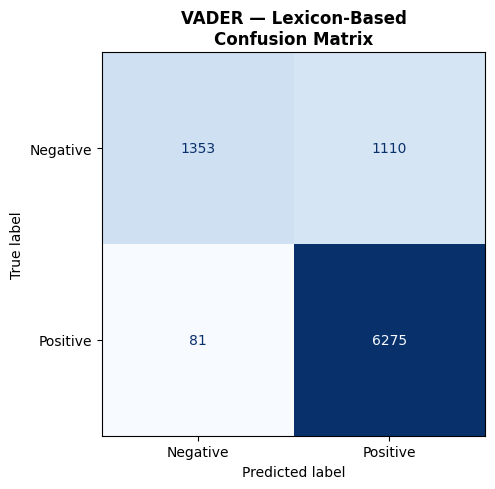

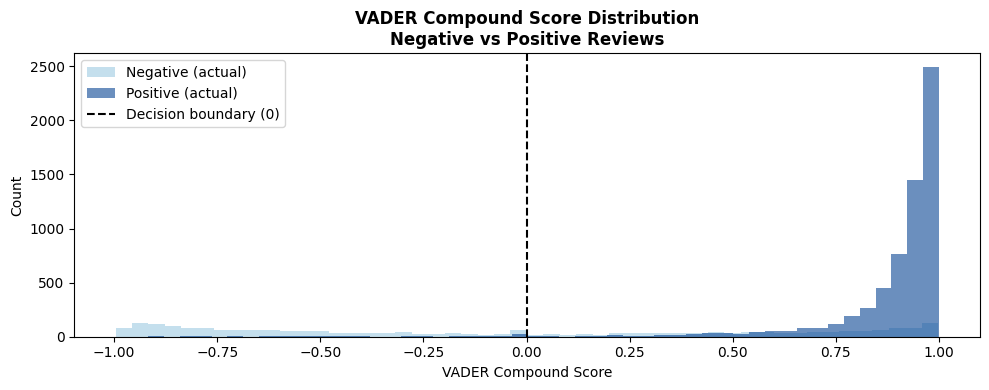


=== COMPLETE MODEL SCOREBOARD ===
  Model                              Accuracy    Neg F1    Pos F1    Training
  ------------------------------------------------------------------------
  NB — Count Vectorizer                91.68%      0.85      0.94    Required
  SVM — Count Vectorizer               94.08%      0.89      0.96    Required
  NB — TF-IDF                          90.53%      0.81      0.94    Required
  SVM — TF-IDF                         94.21%      0.89      0.96    Required
  VADER (lexicon, no training)         86.50%      0.69      0.91        None

  Best ML:    SVM TF-IDF at 94.21%
  VADER gap:  +7.71% vs best ML


In [ ]:
# Code Cell 10 — VADER lexicon-based sentiment analysis

analyzer = SentimentIntensityAnalyzer()

# FIX: use .loc not .iloc — y_test.index contains label-based index values
test_texts_raw = df_binary.loc[y_test.index, 'text'].values

def vader_predict(text):
    score = analyzer.polarity_scores(str(text))['compound']
    return 1 if score >= 0 else 0

print("Running VADER on test set — no training required...")
y_pred_vader = np.array([vader_predict(text) for text in test_texts_raw])

# --- Evaluation ---
vader_accuracy = accuracy_score(y_test, y_pred_vader)

print("\n=== VADER — Lexicon-Based Sentiment ===")
print(f"Accuracy: {vader_accuracy:.4f}  ({vader_accuracy*100:.2f}%)")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_vader,
                             target_names=['Negative (0)', 'Positive (1)']))

# --- Confusion matrix ---
cm_vader = confusion_matrix(y_test, y_pred_vader)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_vader,
                               display_labels=['Negative', 'Positive'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('VADER — Lexicon-Based\nConfusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('vader_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

# --- VADER score distribution ---
vader_scores = [analyzer.polarity_scores(str(t))['compound']
                for t in test_texts_raw]
plt.figure(figsize=(10, 4))
plt.hist([s for s, l in zip(vader_scores, y_test) if l == 0],
         bins=50, alpha=0.6, color='#9ecae1', label='Negative (actual)')
plt.hist([s for s, l in zip(vader_scores, y_test) if l == 1],
         bins=50, alpha=0.6, color='#084594', label='Positive (actual)')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5,
            label='Decision boundary (0)')
plt.title('VADER Compound Score Distribution\nNegative vs Positive Reviews',
          fontweight='bold')
plt.xlabel('VADER Compound Score')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('vader_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Complete final scoreboard ---
neg_f1_vader = f1_score(y_test, y_pred_vader, pos_label=0)
pos_f1_vader = f1_score(y_test, y_pred_vader, pos_label=1)

print("\n=== COMPLETE MODEL SCOREBOARD ===")
print(f"  {'Model':<32} {'Accuracy':>10}  {'Neg F1':>8}  {'Pos F1':>8}  {'Training':>10}")
print(f"  {'-'*72}")
print(f"  {'NB — Count Vectorizer':<32} {'91.68%':>10}  {'0.85':>8}  {'0.94':>8}  {'Required':>10}")
print(f"  {'SVM — Count Vectorizer':<32} {'94.08%':>10}  {'0.89':>8}  {'0.96':>8}  {'Required':>10}")
print(f"  {'NB — TF-IDF':<32} {'90.53%':>10}  {'0.81':>8}  {'0.94':>8}  {'Required':>10}")
print(f"  {'SVM — TF-IDF':<32} {'94.21%':>10}  {'0.89':>8}  {'0.96':>8}  {'Required':>10}")
print(f"  {'VADER (lexicon, no training)':<32} {vader_accuracy*100:>9.2f}%  "
      f"{neg_f1_vader:>8.2f}  {pos_f1_vader:>8.2f}  {'None':>10}")
print(f"\n  Best ML:    SVM TF-IDF at 94.21%")
print(f"  VADER gap:  {(0.9421 - vader_accuracy)*100:+.2f}% vs best ML")

## Text Cell 11 — Model Comparison and Observations

### BLUF

SVM with TF-IDF is the best classifier at 94.21% accuracy. VADER, with zero
training data, reaches 86.50% that reveals a fundamental tradeoff between deployment simplicity and classification precision.
The key finding is in the negative class recall.

### Results

The dataset is imbalanced: 72.1% positive, 27.9% negative. A naive model that
predicts "positive" for every review would score 72% without learning
anything. All five models exceed that baseline in different ways.

**Machine learning models (trained):**

Both SVM variants (94.08% CV, 94.21% TF-IDF) outperform both Naive Bayes
variants (91.68% CV, 90.53% TF-IDF) by ~2-4%.
The model architecture matters more than the feature representation. Switching
from Count Vectorizer to TF-IDF produced only a +0.13% gain for SVM, but
actually hurt Naive Bayes by -1.15%.
The reason: Naive Bayes relies on term frequency as a signal — a review containing "terrible" five times should score more negative than one containing it once. TF-IDF's log normalization compresses that signal. SVM finds optimal decision boundaries that are agnostic to this effect, so TF-IDF's discrimination of distinctive terms helps it marginally.

Negative class F1 across all ML models: 0.81–0.89. The minority class is
harder to classify correctly and where trained data is critical to suucess.

**VADER (lexicon-based, no training):**

VADER achieves 86.50% overall but the classification report tells a more
precise story. Negative class precision: 0.94. Negative class recall: 0.55.
VADER is highly confident when it calls a review negative — it is almost
always right. But it only catches 55% of actual negative reviews, missing
nearly half. It compensates by almost perfectly identifying positive reviews
(recall: 0.99), which inflates the overall accuracy score.

This is the core limitation of the lexicon approach: VADER operates on
explicit sentiment words. A review that says "waited 45 minutes, food arrived
cold, server never came back" contains no strongly negative dictionary words —
yet any human would classify it as negative. The supervised models learn this
pattern from context. VADER never sees it.


## Text Cell 12 — GenAI and Collaboration Acknowledgment

This assignment was completed using an AI-augmented workflow.

All analytical decisions, output
interpretation, and final approval of every cell were made by me.

I directed the research questions and led execution at each step.

No classmates collaborated on this assignment.



In [28]:

!pip install jupyter
!pip install nbconvert
!jupyter nbconvert "/content/drive/MyDrive/Colab Notebooks/LA2_Cook_Matthew.ipynb" --to html

[NbConvertApp] WARNING | pattern '/content/drive/MyDrive/Colab Notebooks/LA2_Cook_Matthew.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: 

In [30]:
!pip install jupyter
!pip install nbconvert
!jupyter nbconvert "/content/drive/MyDrive/Colab Notebooks/LA2_Cook_Matthew.ipynb" --to html

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/LA2_Cook_Matthew.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 7 image(s).
[NbConvertApp] Writing 664765 bytes to /content/drive/MyDrive/Colab Notebooks/LA2_Cook_Matthew.html
